# Binary Classification
---

## Anti-spam model
Vogliamo capire se una recensione è stata lasciata avendo acquistato il prodotto oppure no.
Nel dettaglio, abbiamo pensato di capire tramite un modello se una review pubblicata sembra essere accompagnata dall'acquisto del telefono. <br>
<br>
Questo sistema può essere visto come "anti-spam" perchè una volta ricevuta una recensione che pare avere un forte bias, il modello può verificare se la recensione sembra non accompagnata da un acquisto, e messo in parallelo a qualche software potrebbe mandare una richiesta all'autore della review, per intimare di verificare l'acquisto tramite foto.<br>
Questo porterebbe utenti malevoli a non lasciare recensioni senza poter verificare di avere effettivamente provato il prodotto.

### Import file

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("./data/Mobile Reviews Sentiment.csv")

In [42]:
#verifiche riguardo al dataset
print(df["sentiment"].unique())


['Negative' 'Positive' 'Neutral']


### Impostazione di colonne da analizzare

Andiamo a definire il target e le colonne sulla quale alleneremo il modello

In [43]:
num_features = [
    # Gli altri rating sono fortemente dipendenti da questo
    "rating",
    # Prezzo alto: meno gente ha effettivamente comprato il telefono
    "price_usd",
    # Recensione fasulla: piu corta o lunga del normale
    "review_length",
    "word_count",
]

cat_features = [
    # Un brand è preso maggiormamente di mira
    "brand",
    # Siti sono meno affidabili di altri
    "source",
    "sentiment",
]

TARGET = "verified_purchase"

X = df[num_features + cat_features].copy()
y = df[TARGET].astype(int)

# Per il sentiment che ha solo 3 opzioni
# usiamo l'hot ecoding e trasformiamo il testo
# in variabili numeriche
X = pd.get_dummies(
    X,
    columns=cat_features,
    drop_first=True
)
print(X["sentiment_Neutral"].head(5))
print(X.shape, y.shape)


0    False
1    False
2    False
3    False
4     True
Name: sentiment_Neutral, dtype: bool
(50000, 16) (50000,)


verified_purchase     1.000000
brand_Motorola        0.005372
brand_Google          0.005084
brand_Xiaomi          0.002288
sentiment_Neutral     0.001299
source_eBay           0.000541
price_usd             0.000502
source_Flipkart      -0.000172
rating               -0.000860
brand_Samsung        -0.000932
source_BestBuy       -0.001095
brand_Realme         -0.001231
word_count           -0.001267
sentiment_Positive   -0.002878
review_length        -0.002945
source_Amazon        -0.004412
brand_OnePlus        -0.007136
Name: verified_purchase, dtype: float64


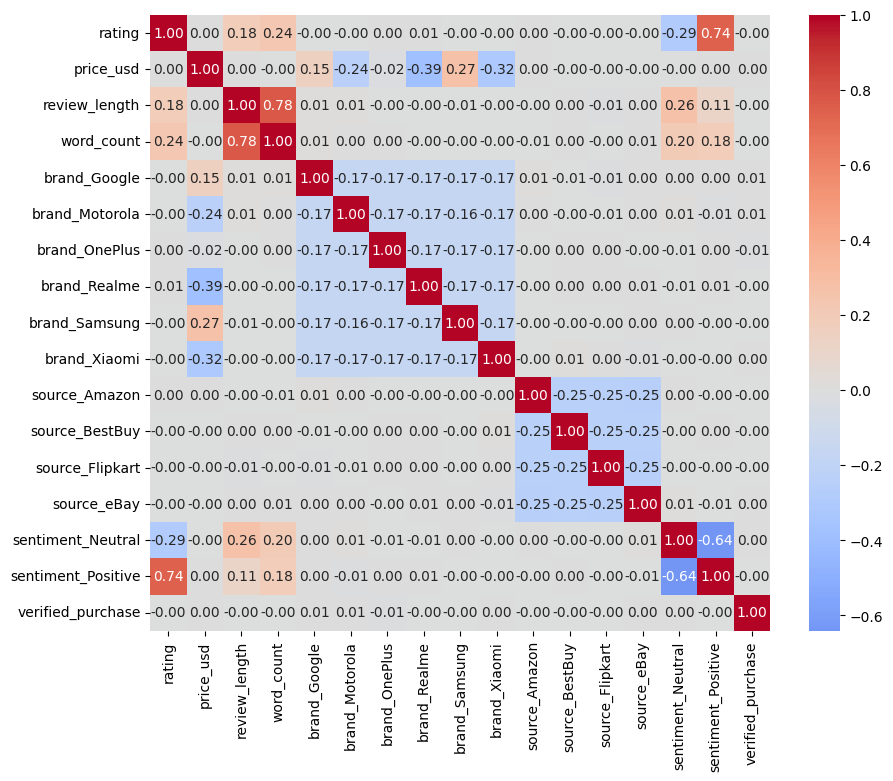

In [44]:
df_corr = X.copy()
df_corr["verified_purchase"] = y.astype(int)
corr_matrix = df_corr.corr(method="pearson")

corr_with_target = corr_matrix["verified_purchase"].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)
plt.show()

### Split del dataset

In [45]:
# X già numerico (dopo get_dummies)
y = df["verified_purchase"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_t = scaler.fit_transform(X_train)
X_test_t  = scaler.transform(X_test)

print("X_train:", X_train_t.shape, "X_test:", X_test_t.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


X_train: (40000, 16) X_test: (10000, 16)
y_train: (40000,) y_test: (10000,)


### Scaling

In [ ]:
# Garantisce stabilità numerica e convergenza del modello
scaler = StandardScaler()
# Dividiamo gia in train e test
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


### Rete neurale

In [47]:

tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train_s.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name="auc")]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

### Calcolo pesi
Essendo che il dataset presenta molti più acquisti verificati che non, assegnamo dei pesi

In [48]:
cw = compute_class_weight(
    class_weight = "balanced",
    classes = np.array([0, 1]),
    y = y_train
)
class_weight = {0: cw[0], 1: cw[1]}
print(class_weight)


{0: np.float64(2.5176233635448138), 1: np.float64(0.6239081607187422)}


In [49]:
# Abbiamo trovato questa configurazione di callback efficace
# che permette di fermare l'addestramento quando la metrica AUC sulla
# validazione non migliora più
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-5
    )
]

# Addestriamo il modello con uno split 20/80
# avendo già diviso il dataset prima però, stiamo 
# in realtà allenando con un 60%~ reale
# un 16% validation e 20% test
history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4913 - auc: 0.4965 - loss: 0.6988 - val_accuracy: 0.4879 - val_auc: 0.5058 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4923 - auc: 0.5071 - loss: 0.6949 - val_accuracy: 0.4799 - val_auc: 0.5068 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4932 - auc: 0.5163 - loss: 0.6937 - val_accuracy: 0.4855 - val_auc: 0.5069 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4946 - auc: 0.5229 - loss: 0.6930 - val_accuracy: 0.4776 - val_auc: 0.5051 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4958 - auc: 0.5285 - loss: 0.6925 - val_accuracy: 0.4746 - val_auc: 0.5043 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4991 - a

### Confusion matrix

Test AUC: 0.48967510532298586
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      1986
           1      0.801     1.000     0.890      8014

    accuracy                          0.801     10000
   macro avg      0.401     0.500     0.445     10000
weighted avg      0.642     0.801     0.713     10000



C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

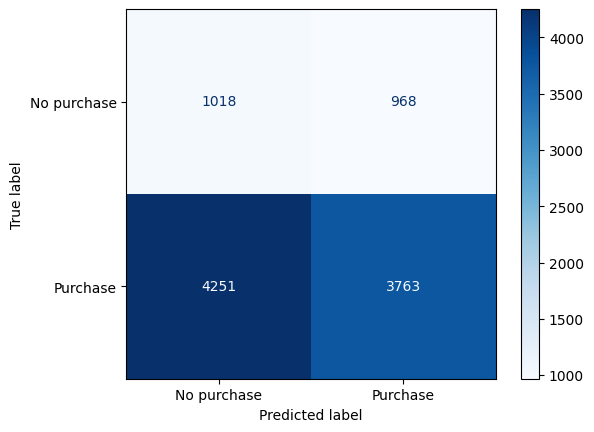

In [53]:

# Probabilità sul test
p = model.predict(X_test_s, verbose=0).ravel()

# AUC
print("Test AUC:", roc_auc_score(y_test, p))
y_pred = (p >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No purchase", "Purchase"]
).plot(cmap="Blues")

plt.show()


### Valutazione del modello
Siamo rimasti un po' delusi nello scoprire che anche usando diverse colonne come feature, il modello non sembra riuscire a distinguere un acquisto verificato da un non verificato.<br>
Ancora adesso non siamo sicuri se sia dato da una certa "onestà" dei clienti, che annullano la differenza tra acquisto verificato e non, oppure se questi dati non sono destinati ad avere alcun tipo di correlazione.<br>
Come vediamo dall'f1 score, e più chiaramente dalla matrice, il modello indovina randomicamente se un acquisto è verificato o no. In ogni caso siamo contenti della pulizia del notebook, e della nostra implementazione, tornando indietro avremmo eseguito più test sul dataset, e magari ci saremmo accorti che cambiarlo poteva essere una buona idea.
